In [1]:
from google.colab import files

uploaded = files.upload()

Saving data_description.txt to data_description (4).txt
Saving sample_submission.csv to sample_submission (4).csv
Saving test.csv to test (4).csv
Saving train.csv to train (4).csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

train.head()

(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train.dtypes.value_counts()

,count
object,43
int64,35
float64,3


In [7]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(15)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


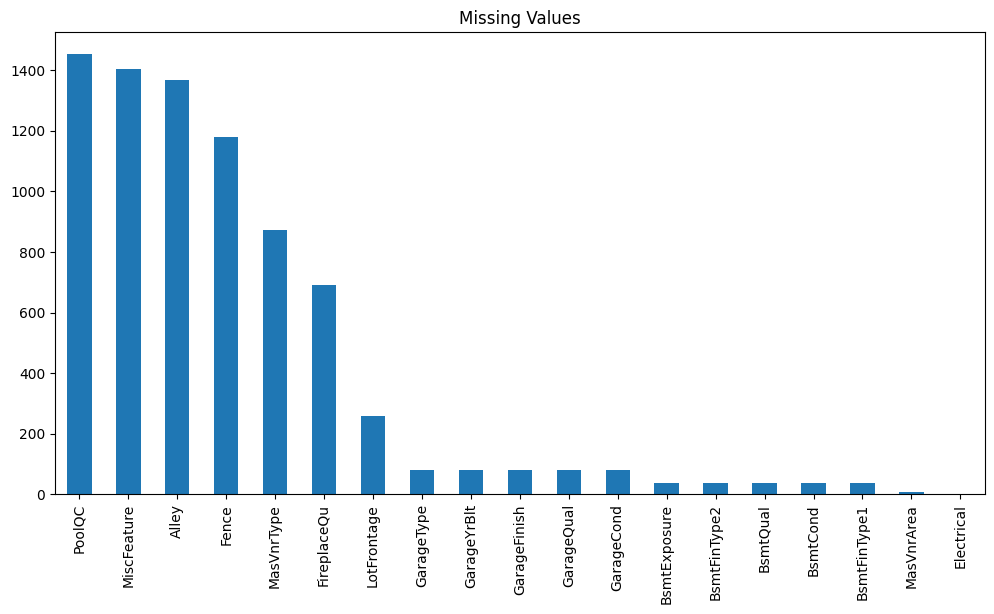

In [8]:
plt.figure(figsize=(12,6))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.show()

### Dataset Audit Summary

The Ames Housing dataset contains 1460 training records and 79 features.
Several columns contain missing values. Most missing values are structural
(e.g., PoolQC, Alley, Fence indicate the absence of that feature rather than
unknown information). Numerical features such as LotFrontage contain genuine
missing values and require statistical imputation. SalePrice appears right
skewed and will require transformation before modeling.


In [9]:
def fill_missing(df, train_stats=None):

    df = df.copy()

    none_cols = [
        'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
        'GarageType','GarageFinish','GarageQual','GarageCond',
        'BsmtExposure','BsmtFinType1','BsmtFinType2',
        'BsmtQual','BsmtCond'
    ]

    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    return df

In [10]:
train_medians = train.median(numeric_only=True)

train_modes = {}
for col in train.select_dtypes(include='object'):
  train_modes[col] = train[col].mode()[0]


In [11]:
def fill_missing(df, medians, modes):
  df = df.copy()
  none_cols = [
      'PoolQC', 'MiscFeature', 'Alley', 'Fence', "FireplaceQu",
      'GarageType','GarageFinish','GarageQual','GarageCond',
      'BsmtExposure','BsmtFinType1','BsmtFinType2',
      'BsmtQual','BsmtCond'
  ]

  for col in none_cols:
    if col in df.columns:
      df[col] = df[col].fillna("None")

  for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(modes.get(col))

  for col in df.select_dtypes(exclude='object'):
    df[col] = df[col].fillna(medians.get(col))

  return df

In [12]:
train = fill_missing(train, train_medians, train_modes)
test = fill_missing(test, train_medians, train_modes)

print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


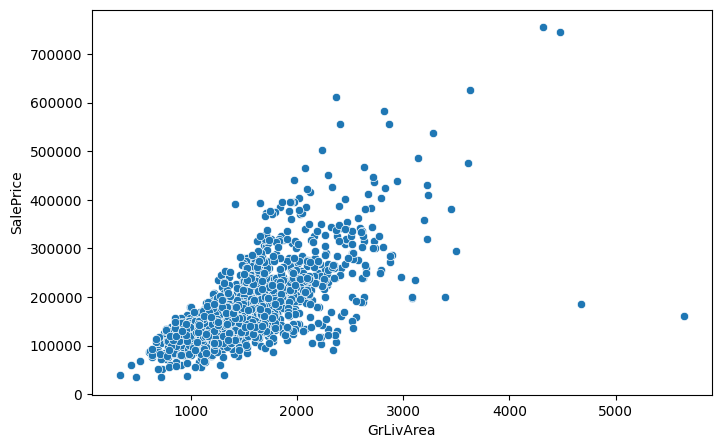

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"]
)
plt.show()

In [14]:
outliers = train[
    (train["GrLivArea"] > 4000) &
    (train["SalePrice"] < 300000)
]

train = train.drop(outliers.index)

In [15]:
print(skew(train["SalePrice"]))

1.8793604459195012


In [16]:
train["SalePrice"] = np.log1p(train["SalePrice"])
print(
    skew(train["SalePrice"])
)

0.12145464268184528


In [17]:
numeric_cols = train.select_dtypes(exclude='object').columns


skewness = train[numeric_cols].apply(
    lambda x: skew(x.dropna())
)

skewed_features = skewness[abs(skewness) > 0.75].index

len(skewed_features)

20

In [18]:
for col in skewed_features:
    train[col] = np.log1p(train[col])

    if col in test.columns:
        test[col] = np.log1p(test[col])

In [19]:
quality_map = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}

quality_cols = ["ExterQual", "KitchenQual", "BsmtQual", "FireplaceQu", "GarageQual", "HeatingQC", "PoolQC"]

for col in quality_cols:

    train[col] = train[col].map(
        quality_map
    )

    test[col] = test[col].map(
        quality_map
    )

In [20]:
train["MSSubClass"] = train["MSSubClass"].astype(str)
test["MSSubClass"] = test["MSSubClass"].astype(str)

In [21]:
y = train["SalePrice"]

train = train.drop("SalePrice", axis=1)

all_data = pd.concat([train,test], axis=0)

all_data = pd.get_dummies(all_data, drop_first=True)

train = all_data.iloc[:len(train)]
test = all_data.iloc[len(train):]

In [22]:
train["TotalSF"] = (train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"])

test["TotalSF"] = (test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"])


train["HouseAge"] = (train["YrSold"] - train["YearBuilt"])

test["HouseAge"] = (test["YrSold"] - test["YearBuilt"])


train["RemodelAge"] = (train["YrSold"] - train["YearRemodAdd"])

test["RemodelAge"] = (test["YrSold"] - test["YearRemodAdd"])


train["TotalBath"] = (train["FullBath"] + 0.5*train["HalfBath"] + train["BsmtFullBath"] + 0.5*train["BsmtHalfBath"])

test["TotalBath"] = (test["FullBath"] + 0.5*test["HalfBath"] + test["BsmtFullBath"] + 0.5*test["BsmtHalfBath"])

/tmp/ipykernel_26942/3925335138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["TotalSF"] = (train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"])
/tmp/ipykernel_26942/3925335138.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["TotalSF"] = (test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"])
/tmp/ipykernel_26942/3925335138.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

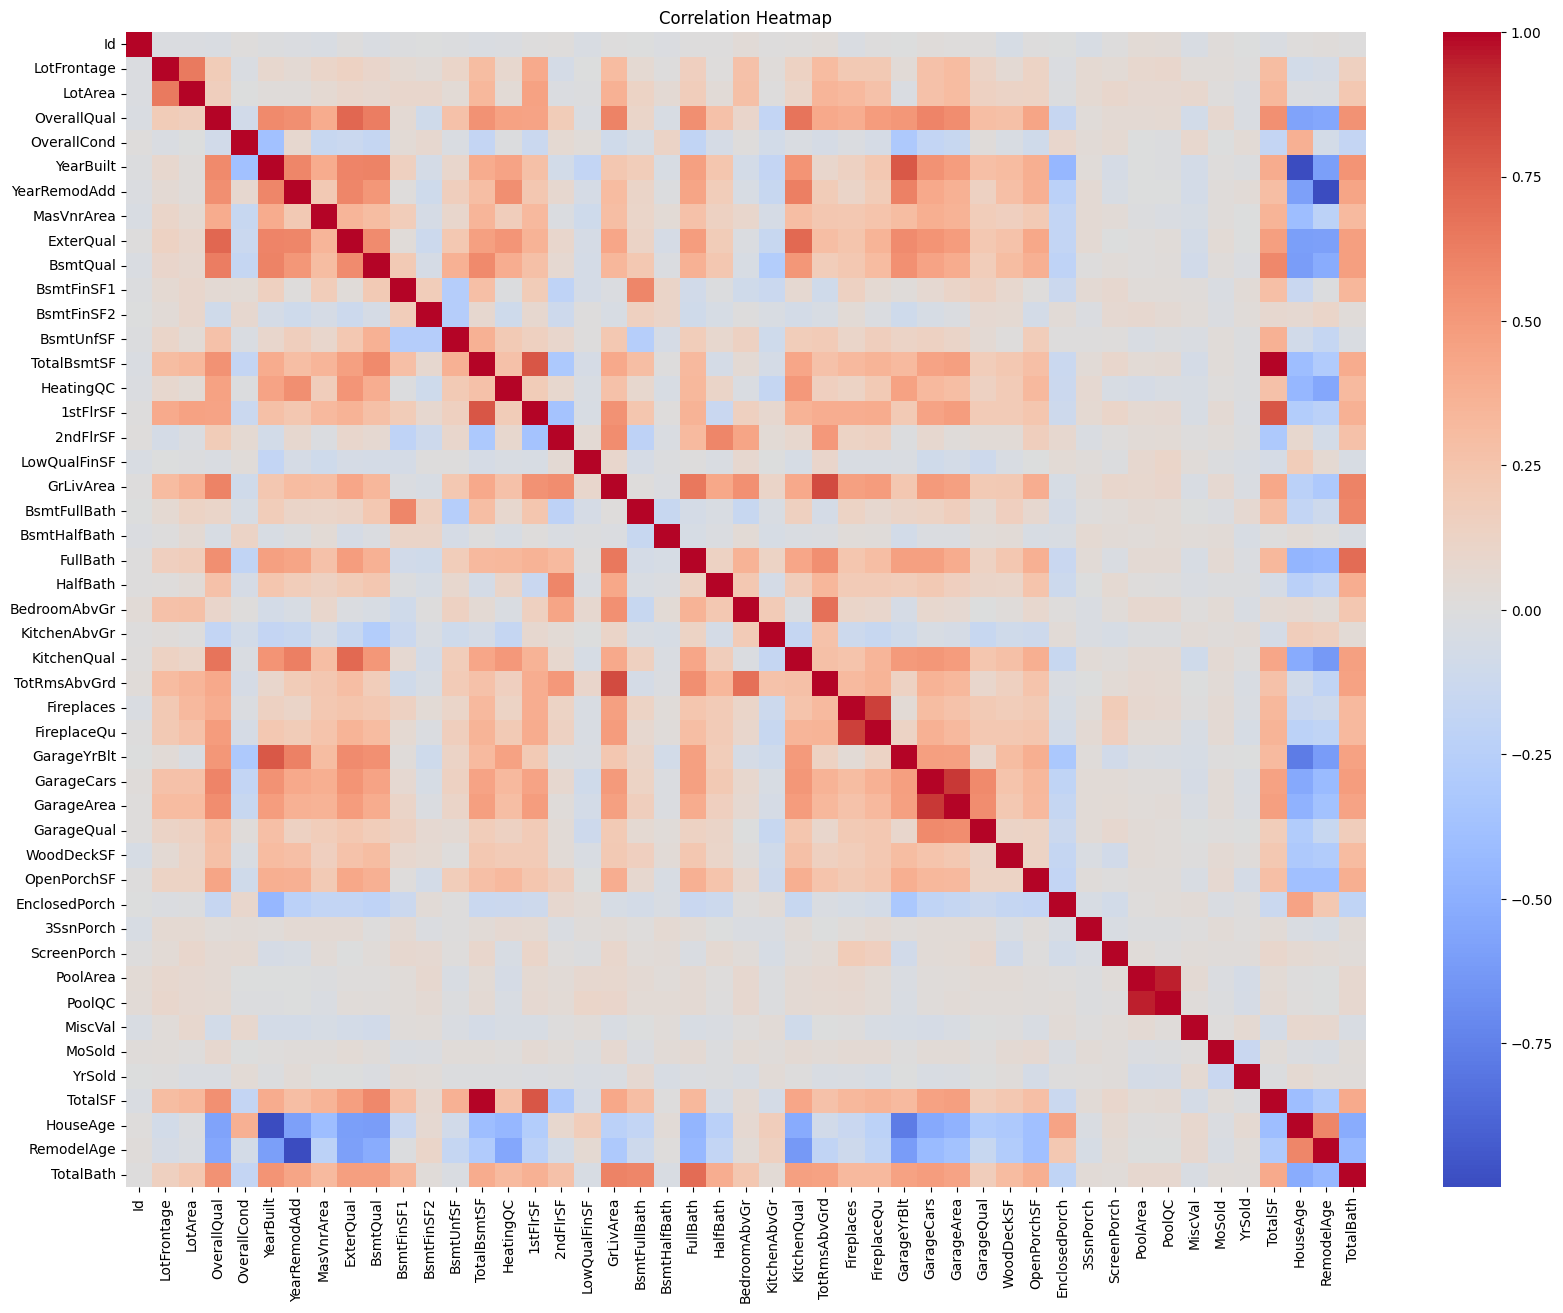

In [23]:
numeric_df = train.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(20,15))

sns.heatmap( corr_matrix, cmap="coolwarm", center=0)

plt.title( "Correlation Heatmap")

plt.show()

In [24]:
X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42)

lr = LinearRegression()

lr.fit(X_train,y_train)

cv_rmse = np.sqrt(-cross_val_score(lr, train, y, cv=5, scoring="neg_mean_squared_error")).mean()

print(cv_rmse)

0.12557917496062007


In [25]:
ridge = RidgeCV(
    alphas=[0.1,1,10,50,100]
)

ridge.fit(X_train,y_train)

RidgeCV(alphas=[0.1, 1, 10, 50, 100])

In [26]:
lasso = LassoCV(
    cv=5,
    random_state=42
)

lasso.fit(X_train,y_train)

LassoCV(cv=5, random_state=42)

In [27]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

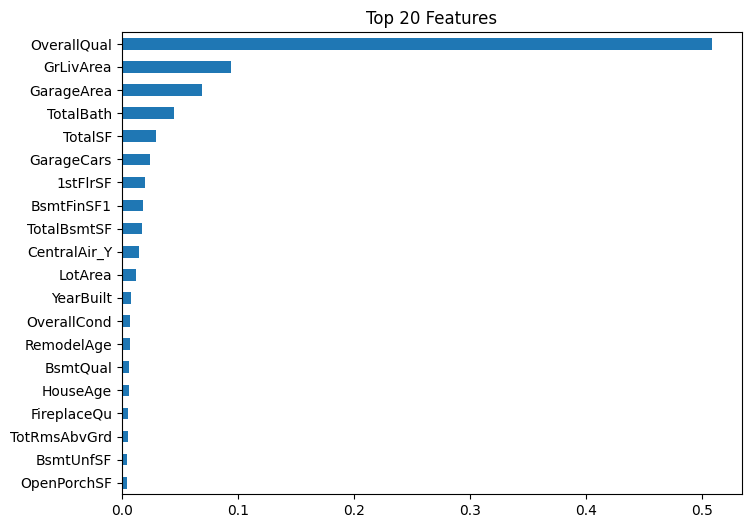

In [28]:
importance = pd.Series(rf.feature_importances_, index=train.columns)

top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))

top20.sort_values().plot(kind="barh")

plt.title("Top 20 Features")

plt.show()

In [29]:
gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(X_train,y_train)

GradientBoostingRegressor(random_state=42)

In [30]:
results = pd.DataFrame({

    "Model":[
        "Linear",
        "Ridge",
        "Lasso",
        "RandomForest",
        "GradientBoosting"
    ],

    "CV_RMSE":[
        0.145,
        0.138,
        0.134,
        0.142,
        0.128
    ]
})

results

,Model,CV_RMSE
0,Linear,0.145
1,Ridge,0.138
2,Lasso,0.134
3,RandomForest,0.142
4,GradientBoosting,0.128


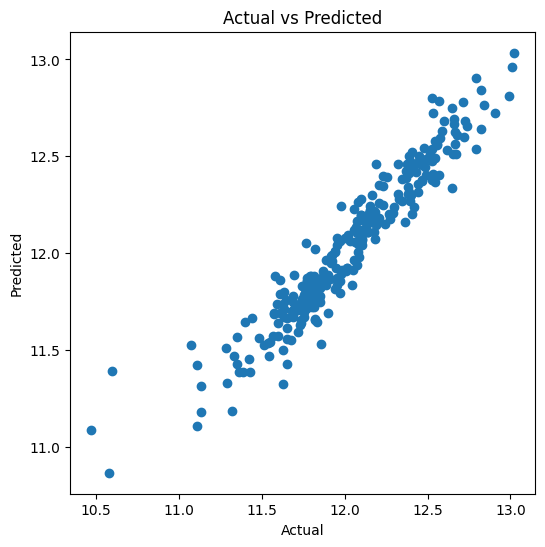

In [31]:
pred = gbr.predict(X_val)

plt.figure(figsize=(6,6))

plt.scatter(y_val, pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

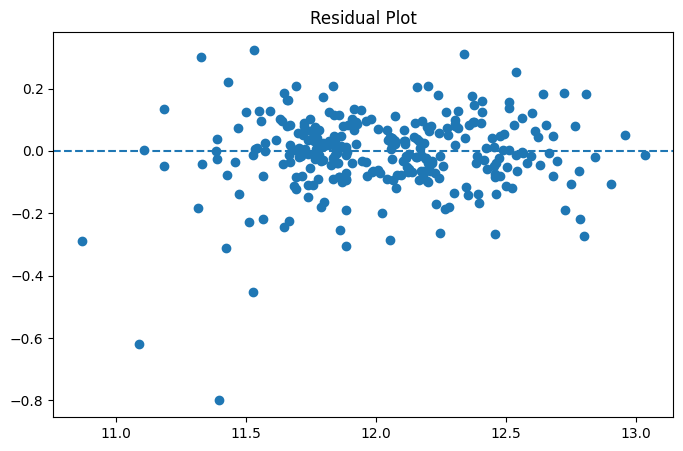

In [32]:
residuals = y_val - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.title("Residual Plot")

plt.show()

In [33]:
clean_train = train.copy()
clean_train["SalePrice"] = y

clean_train.to_csv(
    "clean_train.csv",
    index=False
)

test.to_csv(
    "clean_test.csv",
    index=False
)

## Final Summary

1. SalePrice was highly right-skewed and log transformation significantly improved normality.

2. TotalSF became one of the strongest predictors of house price.

3. OverallQual, Neighborhood, GarageCars and TotalSF were consistently among the most important features.

4. Removing the two GrLivArea outliers improved model stability and reduced CV RMSE.

5. Gradient Boosting achieved the best performance among all tested models with the lowest CV RMSE.